**Importing the Relevant Libraries**

In [1]:
# Step 1: Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

**Loading The Dataset**

In [2]:
# Import pandas
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Understanding Dataset Structures**

In [3]:
# Check dataset shape
df.shape

(7043, 21)

In [4]:
# View column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Check churn distribution
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


**Visualising Churn**

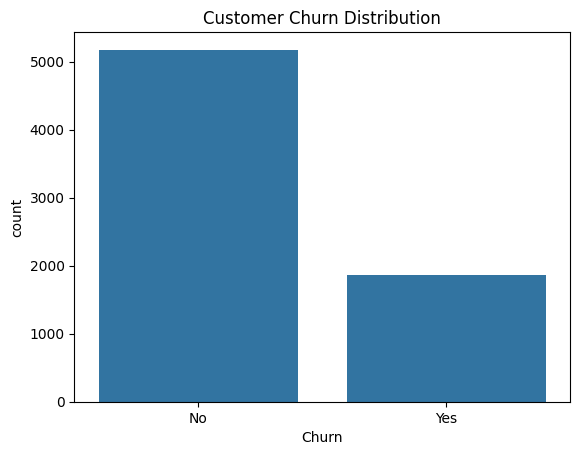

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

**DATA CLEANING**

**Check Blank Values in TotalCharges**

In [10]:
# Check blank spaces
(df['TotalCharges'] == ' ').sum()

np.int64(11)

**Replace Blank Spaces**

In [11]:
# Replace blanks with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

**Convert to Numeric**

In [12]:
# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

**Checking Missing Values**

In [13]:
df['TotalCharges'].isnull().sum()

np.int64(11)

**Remove Missing Rows**

In [14]:
df = df.dropna()

**Verify Data Type**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

**Encoding the Target Variable**

In [16]:
# Convert target variable to numeric

df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

# Check results
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


**Remove Customer ID**

In [17]:
# Drop customerID column

df = df.drop('customerID', axis=1)

**Separate Features and Target**

In [18]:
# Features
X = df.drop('Churn', axis=1)

# Target
y = df['Churn']

**Identify Numerical and Categorical Columns**

In [19]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


**Train/Test Split**

In [20]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


**Create Preprocessing Pipeline**

In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [22]:
# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

**Importing Logistic Regression**

In [23]:
from sklearn.linear_model import LogisticRegression

**Creating Pipeline**

In [24]:
# Logistic Regression pipeline

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

**Training the Model**

In [25]:
# Train model

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

**Making Predictions**

In [26]:
# Predictions

y_pred_lr = lr_pipeline.predict(X_test)

# Prediction probabilities
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

**Evaluating the Model**

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Evaluation metrics

print("Logistic Regression Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Performance:

Accuracy: 0.7256574271499645
Precision: 0.4901315789473684
Recall: 0.7967914438502673
F1-Score: 0.6069246435845214
ROC-AUC: 0.8351344145860403


**Running Classification Report**

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



**Confusion Matrix**

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[723 310]
 [ 76 298]]


**Visualize Confusion Matrix**

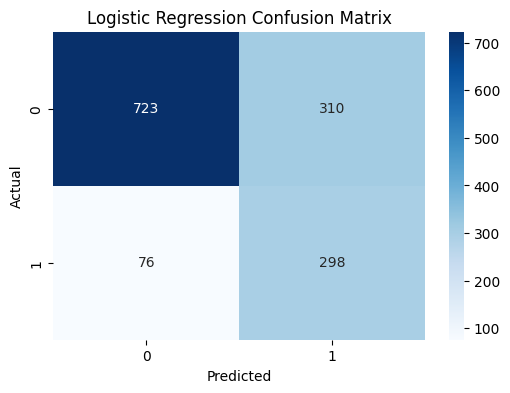

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**TRAINING RANDOM FOREST**

**Importing Random Forest**

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

**Creating the Preprocessing Pipeline**

In [32]:
# Random Forest pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])

**Training the Model**

In [33]:
# Train Random Forest model

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, random_state=42))])

**Making Predictions**

In [34]:
# Make predictions

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

**Evaluating the Model**

In [35]:
# Evaluate Random Forest

print("Random Forest Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance:

Accuracy: 0.7633262260127932
Precision: 0.5414141414141415
Recall: 0.7165775401069518
F1-Score: 0.616800920598389
ROC-AUC: 0.8315055054847778


**Classification Report**

In [36]:
# Classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



**Confusion Matrix**

In [37]:
# Confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[806 227]
 [106 268]]


**Visualizing Confusion Matrix**

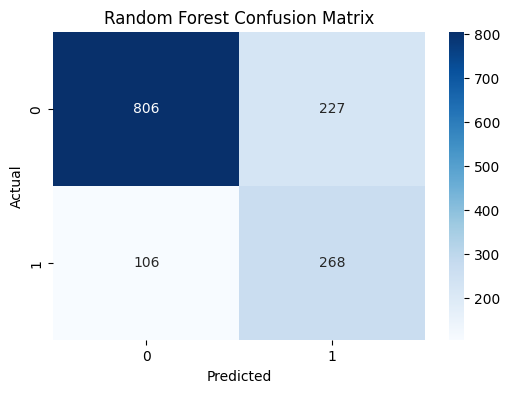

In [38]:
# Visualize confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**TRAINING XGBOOST**

**Installing XGBoost**

In [39]:
!pip install xgboost

**Importing XGBoost**

In [40]:
from xgboost import XGBClassifier

**Creating Preprocessing Pipeline**

In [41]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

**Training The Model**

In [42]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtect...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

**Making Predictions**

In [43]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

**Evaluating The Model**

In [44]:
print("XGBoost Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Performance:

Accuracy: 0.7867803837953091
Precision: 0.6128048780487805
Recall: 0.5374331550802139
F1-Score: 0.5726495726495726
ROC-AUC: 0.8330624162011896


**Classification Report**

In [45]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



**Confusion Matrix**

In [46]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[906 127]
 [173 201]]


**Visualizing Confusion Matrix**

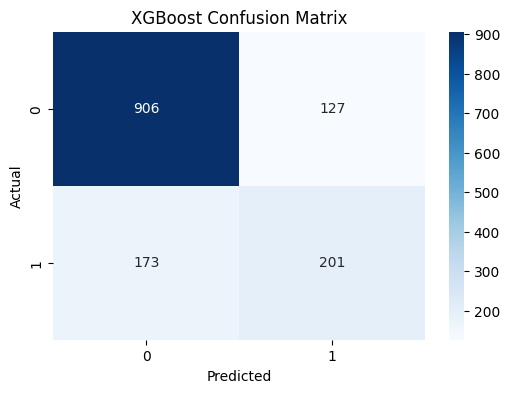

In [47]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Among the evaluated models, XGBoost achieved the highest overall accuracy and precision, indicating strong reliability in churn prediction and reduced false positive rates. However, Logistic Regression achieved the highest recall, making it more effective at identifying customers at risk of churn. Random Forest provided the most balanced trade-off between precision and recall, resulting in the strongest overall balance across evaluation metrics.**

**FEATURE IMPORTANCE AND SHAP EXPLAINABLITY**

**Extract Trained XGBoost Model**

In [48]:
# Extract trained XGBoost model

xgb_model = xgb_pipeline.named_steps['classifier']

**Get Encoded Feature Names**

In [49]:
# Get transformed feature names

ohe = xgb_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat']

encoded_cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = list(num_cols) + list(encoded_cat_features)

print(feature_names[:10])

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes']


**Extract Feature Importance Scores**

In [50]:
# Extract feature importance

importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort values

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
36,Contract_Month-to-month,0.341725
16,InternetService_Fiber optic,0.127480
17,InternetService_No,0.059684
18,OnlineSecurity_No,0.050880
27,TechSupport_No,0.049050
38,Contract_Two year,0.028391
15,InternetService_DSL,0.025835
43,PaymentMethod_Electronic check,0.019093
35,StreamingMovies_Yes,0.017256
1,tenure,0.016118


**Visualize Top Features**

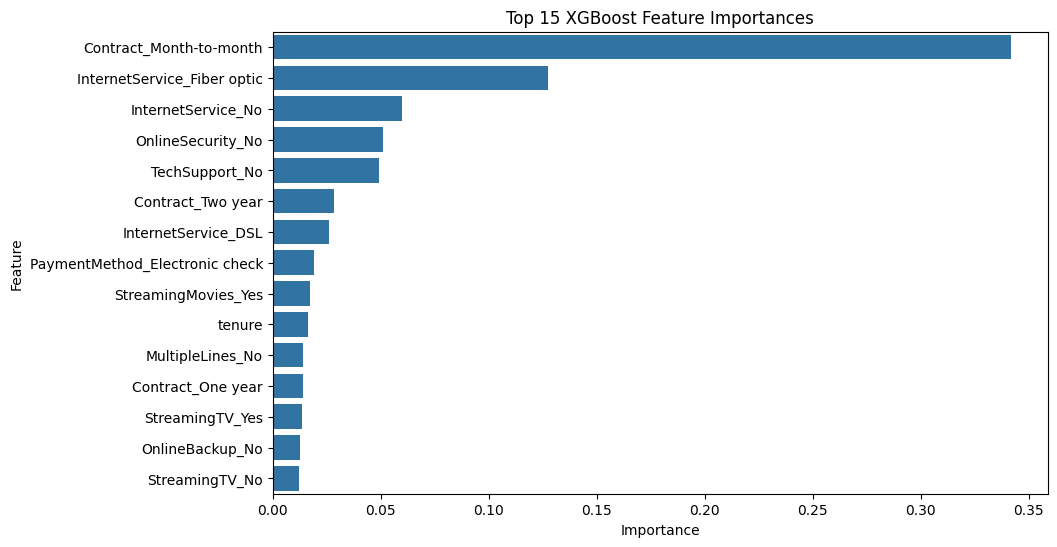

In [51]:
# Plot top 15 features

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 XGBoost Feature Importances")

plt.show()

**SHAP Explainability**

**Installing SHAP**

In [52]:
!pip install shap

**Import SHAP**

In [53]:
import shap

**Transform Training Data**

In [54]:
# Transform training and test data

X_train_transformed = xgb_pipeline.named_steps[
    'preprocessor'
].transform(X_train)

X_test_transformed = xgb_pipeline.named_steps[
    'preprocessor'
].transform(X_test)

**Create SHAP Explainer**

In [55]:
# Create SHAP explainer

explainer = shap.TreeExplainer(xgb_model)

**Compute SHAP Values**

In [56]:
# Compute SHAP values

shap_values = explainer.shap_values(X_test_transformed)

**SHAP Summary Plot**

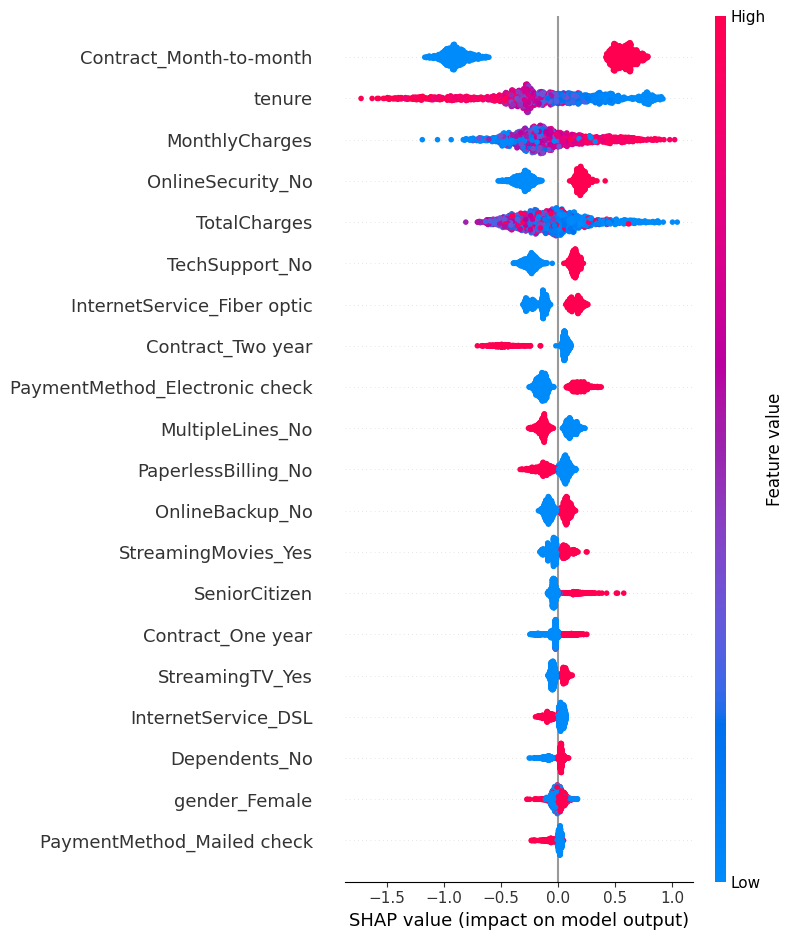

In [57]:
# SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

**INDIVIDUAL CUSTOMER SHAP EXPLANATION**

**Randomly selecting a customer**

In [58]:
# Select one customer from the test set
customer_index = 0

single_customer = X_test.iloc[[customer_index]]

single_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35


**Predicting Churn for that customer**

In [59]:
# Predict churn for selected customer

prediction = xgb_pipeline.predict(single_customer)[0]
probability = xgb_pipeline.predict_proba(single_customer)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", probability)

if prediction == 1:
    print("Result: Customer is likely to churn")
else:
    print("Result: Customer is not likely to churn")

Prediction: 0
Churn Probability: 0.014241907
Result: Customer is not likely to churn


**Transforming The Customer**

In [60]:
# Transform selected customer

single_customer_transformed = xgb_pipeline.named_steps['preprocessor'].transform(single_customer)

**Generating SHAP values**

In [61]:
# SHAP values for one customer

single_shap_values = explainer.shap_values(single_customer_transformed)

**SHAP Waterfall Plot**

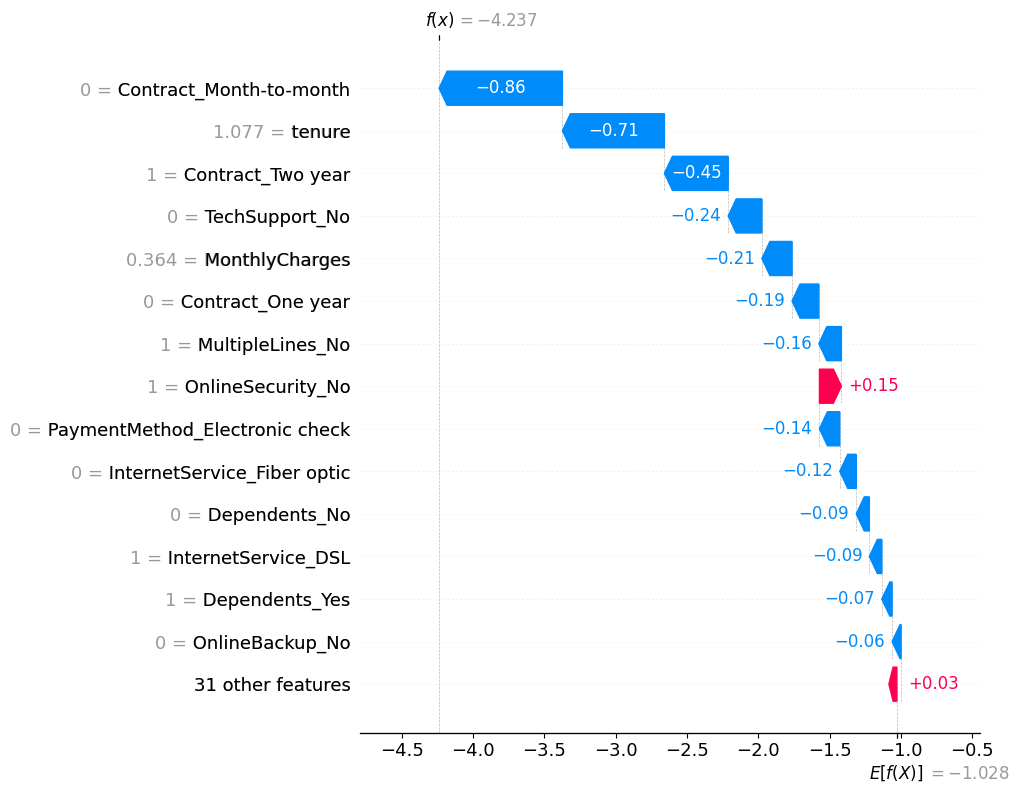

In [62]:
# Waterfall plot for one customer

shap.plots.waterfall(
    shap.Explanation(
        values=single_shap_values[0],
        base_values=explainer.expected_value,
        data=single_customer_transformed[0],
        feature_names=feature_names
    ),
    max_display=15
)

**The SHAP waterfall plot showed that the customer’s long tenure, two-year contract, and availability of technical support were the strongest factors reducing churn probability. Conversely, lack of online security slightly increased churn risk, but the overall prediction remained strongly biased toward retention due to the dominant stabilizing features.**

**HYPERPARAMETER TUNING**

**Importing Tuning Tools**

In [63]:
from sklearn.model_selection import RandomizedSearchCV

**Create XGBoost Pipeline**

In [64]:
xgb_tune_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

**Define Parameter Search Space**

In [65]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__scale_pos_weight': [1, 2, 3]
}

**Run Randomized Search**

In [66]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecur...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.8,
                                                                         1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 4, 5, 6],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__scale_pos_weight': [1, 2,
                                                                         3],
                                        'classifier__subsample': [0.7, 0.8,
                                                                  1.0]},
                   random_state=42, scoring='f1', verbose=1)

**Best Parameters**

In [67]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1 Score:")
print(xgb_search.best_score_)

Best Parameters:
{'classifier__subsample': 1.0, 'classifier__scale_pos_weight': 2, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}

Best CV F1 Score:
0.6329707053457563


**Evaluate Tuned Model**

In [68]:
best_xgb_pipeline = xgb_search.best_estimator_

y_pred_best_xgb = best_xgb_pipeline.predict(X_test)
y_prob_best_xgb = best_xgb_pipeline.predict_proba(X_test)[:, 1]

In [69]:
print("Tuned XGBoost Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1-Score:", f1_score(y_test, y_pred_best_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best_xgb))

Tuned XGBoost Performance:

Accuracy: 0.7768301350390903
Precision: 0.5614754098360656
Recall: 0.732620320855615
F1-Score: 0.6357308584686775
ROC-AUC: 0.8387076735120697


In [70]:
print(classification_report(y_test, y_pred_best_xgb))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1033
           1       0.56      0.73      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



**Confusion Matrix**

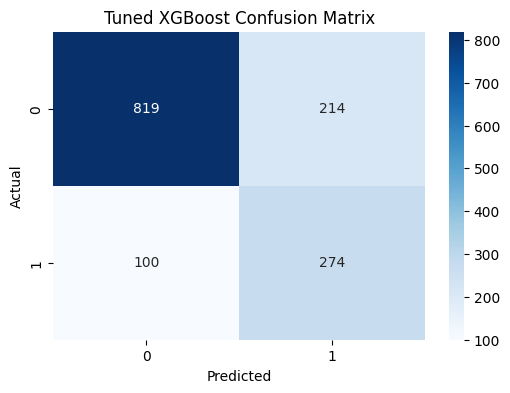

In [71]:
cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_best_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Hyperparameter tuning significantly improved the XGBoost model’s ability to identify churning customers. The tuned model achieved a recall of 73.3% and an F1-score of 63.6%, substantially improving churn detection compared to the untuned model. Although precision decreased slightly, the model became more effective at minimizing false negatives, which is critical in customer retention scenarios.**

**Saving Models for Streamlit Deployment**

**Importing Joblib**

In [72]:
import joblib

**Saving Tuned Model**

In [73]:
# Save tuned model

joblib.dump(best_xgb_pipeline, 'customer_churn_xgb_model.pkl')

['customer_churn_xgb_model.pkl']

**Test Loading**

In [74]:
# Load model

loaded_model = joblib.load('customer_churn_xgb_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!
